## Phase 1: Load and Understand Data

In [1]:
import pandas as pd

df = pd.read_csv('European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [4]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.columns.tolist()

['Year',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

## Phase 2: Data Cleaning

In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#removing uncessary columns
df.drop(columns = ['CustomerId','Surname'], inplace = True)

In [9]:
df['Year'].unique()

array([2025])

In [10]:
# Year is constant, so it adds nothing to the model - dropping it
df.drop(columns=['Year'], inplace=True)

In [11]:
df.columns.tolist()

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

## Phase 3: Target Analysis

In [12]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [13]:
#percentage
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

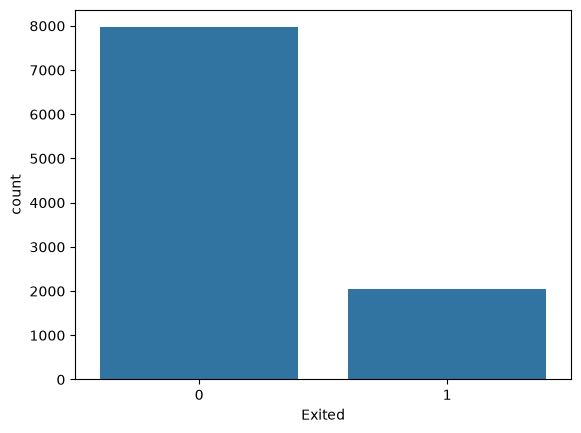

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = 'Exited', data = df)
plt.show()

- Almost 20% customers left(churned)

## Phase 4: Univariate EDA

In [15]:
num_cols = df.select_dtypes(include=[int,float]).columns.to_list()
remove_num_cols = ['Year','HasCrCard','Exited']
num_cols = [i for i in num_cols if i not in remove_num_cols]
num_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'IsActiveMember',
 'EstimatedSalary']

In [16]:
num_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'IsActiveMember',
 'EstimatedSalary']

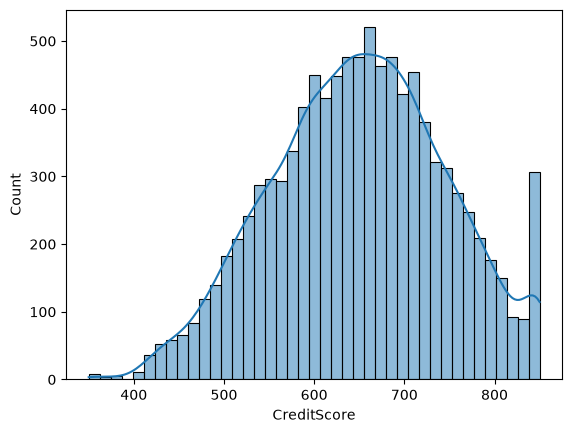

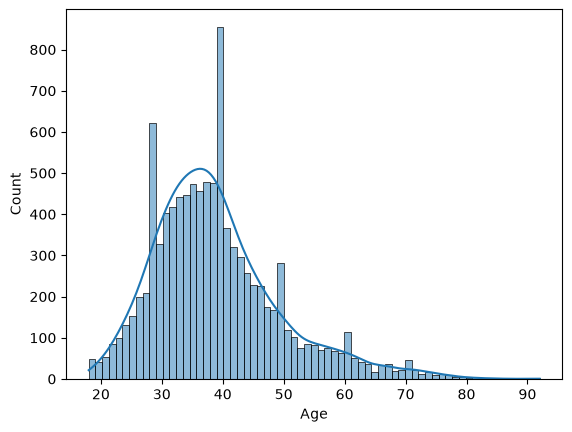

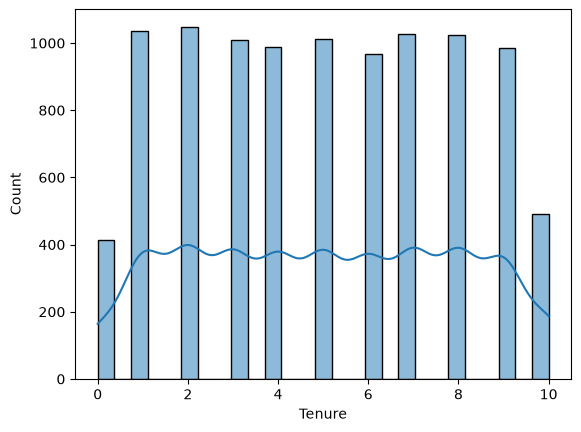

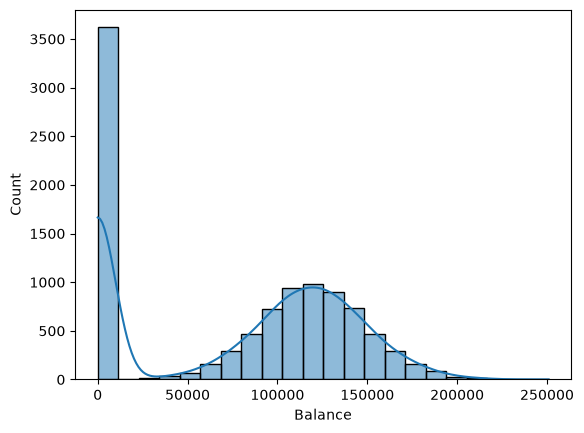

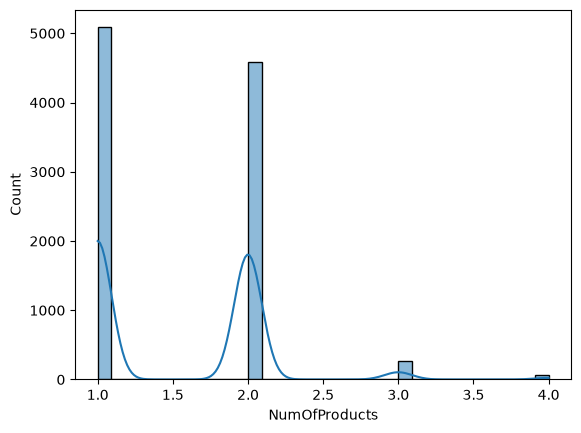

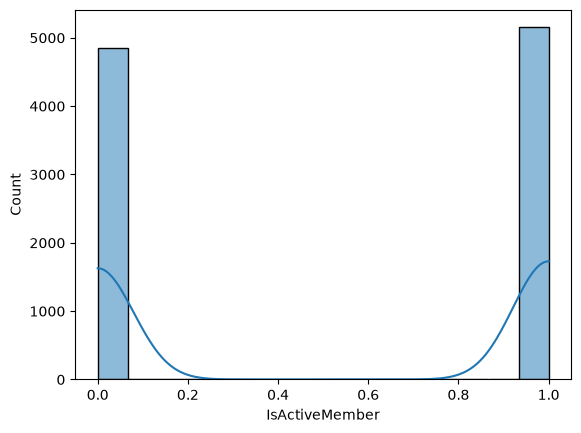

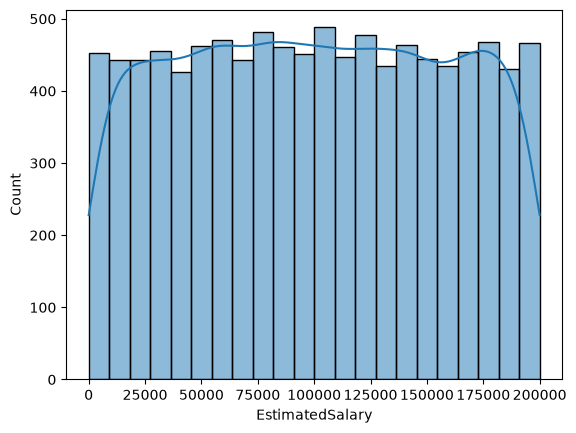

In [17]:
for i in num_cols:
    sns.histplot(df[i], kde = True)
    plt.show()

**Observations from Univariate EDA on Numerical Columns:**
-	Majority of customers have credit score between 600 to 700.
-	Most customer’s age range between 25 to 45.
-	Most customers have tenure from 1 to 9 years.
-	Customers having 0 balance are more.
-	Customers having products 1 and 2 are more.
-	The estimated salary of the customers is well balanced and ranges between 0 to 200000


In [18]:
cat_cols = [
    'Geography','Gender'
]

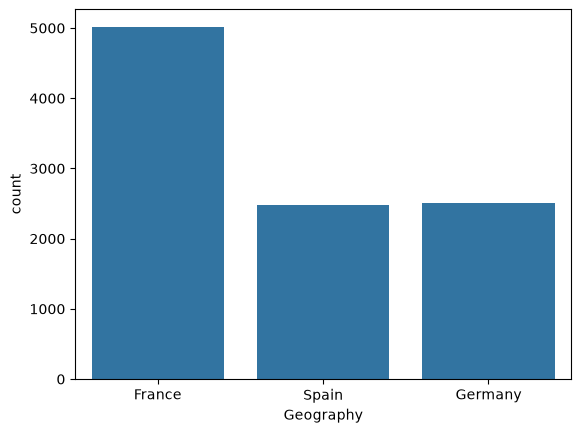

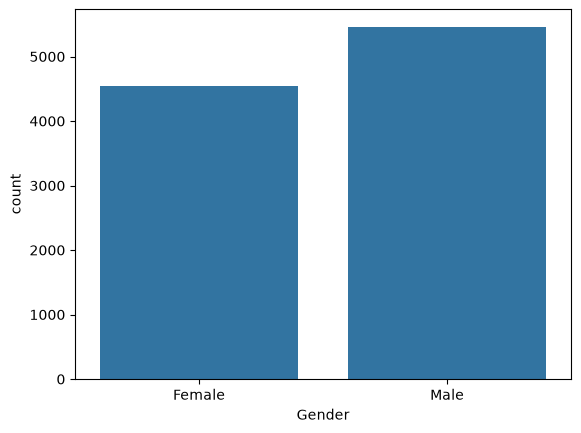

In [19]:
for i in cat_cols:
    sns.countplot(x = i, data=df)
    plt.show()

**Observations from Univariate EDA on Categorical Columns:**
-	We have more customers from France than Spain and Germany, comparatively double than the other two countries respectively.

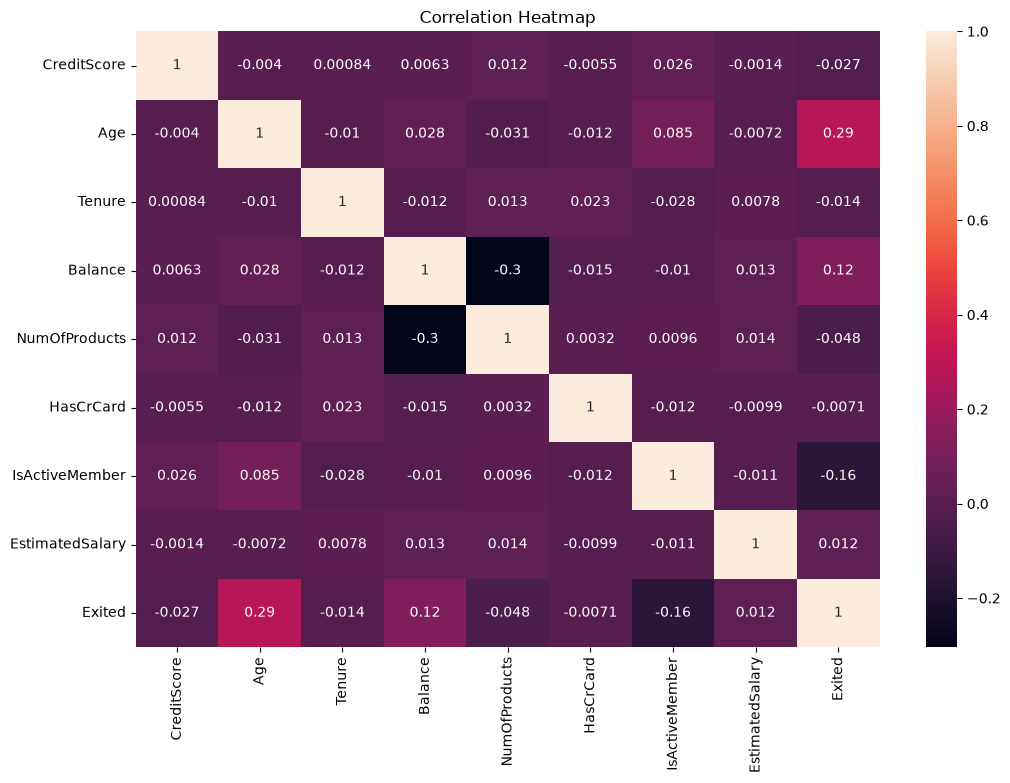

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot = True)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
numeric_df = df.select_dtypes(include = [int,float])
target_corr = numeric_df.corr()['Exited'].drop('Exited').sort_values(key = abs, ascending=False)
print(target_corr)

Age                0.285323
IsActiveMember    -0.156128
Balance            0.118533
NumOfProducts     -0.047820
CreditScore       -0.027094
Tenure            -0.014001
EstimatedSalary    0.012097
HasCrCard         -0.007138
Name: Exited, dtype: float64


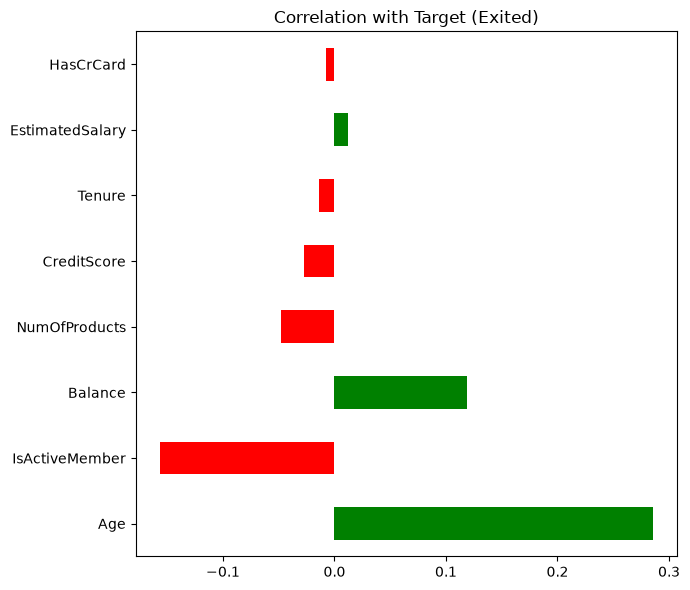

In [22]:
plt.figure(figsize=(7,6))
target_corr.plot(kind='barh', color=['green' if v > 0 else 'red' for v in target_corr])
plt.title('Correlation with Target (Exited)')
plt.tight_layout()
plt.show()

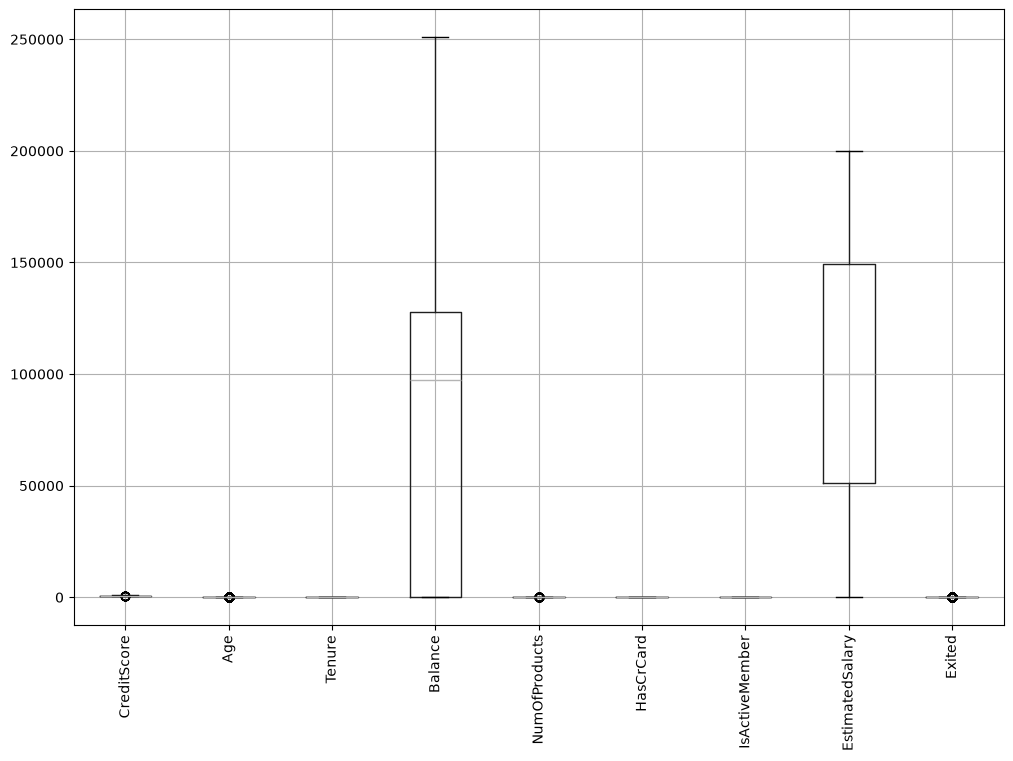

In [23]:
plt.figure(figsize=(12,8))
df.boxplot(rot=90)
plt.show()

**Observations from EDA**
- 'Age' and 'IsActiveMember' are strongly correlated with the target column 'Exited'. 'Balance' is moderately correlated with the target column 'Exited'.
- No outlier is present in the data.
- No empty value is present.

## Phase 5: Business Analysis

In [24]:
# creating engagement segments based on activity and product count
def engagement_segment(row):
    if row['IsActiveMember'] == 1:
        if row['NumOfProducts'] >= 2:
            return 'Active Engaged'
        else:
            return 'Active Low-Product'
    else:
        if row['Balance'] > df['Balance'].median():
            return 'Inactive High-Balance'
        else:
            return 'Inactive Disengaged'

df['EngagementSegment'] = df.apply(engagement_segment, axis=1)
df['EngagementSegment'].value_counts()

EngagementSegment
Active Engaged           2588
Active Low-Product       2563
Inactive High-Balance    2456
Inactive Disengaged      2393
Name: count, dtype: int64

In [25]:
# churn rate by engagement segment
df.groupby('EngagementSegment')['Exited'].mean()

EngagementSegment
Active Engaged           0.096600
Active Low-Product       0.189231
Inactive Disengaged      0.212286
Inactive High-Balance    0.323290
Name: Exited, dtype: float64

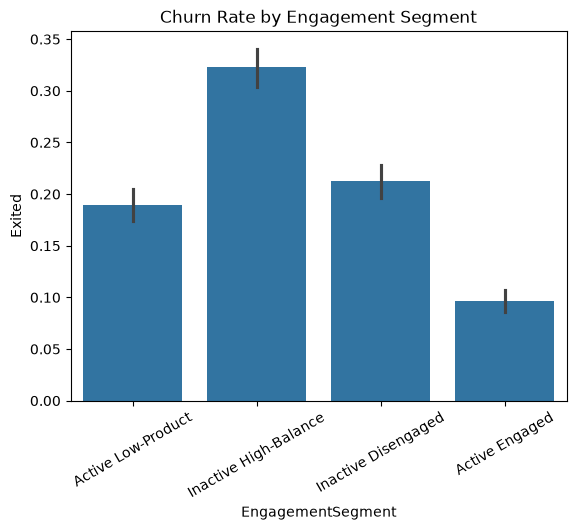

In [26]:
sns.barplot(x='EngagementSegment', y='Exited', data=df)
plt.title('Churn Rate by Engagement Segment')
plt.xticks(rotation=30)
plt.show()

### Financial Commitment vs Engagement Analysis

In [27]:
# salary-balance mismatch detection
salary_median = df['EstimatedSalary'].median()
balance_median = df['Balance'].median()

df['SalaryBalanceMismatch'] = ((df['EstimatedSalary'] > salary_median) & (df['Balance'] < balance_median)).astype(int)
df['SalaryBalanceMismatch'].value_counts()

SalaryBalanceMismatch
0    7516
1    2484
Name: count, dtype: int64

In [28]:
# churn rate for mismatch customers
df.groupby('SalaryBalanceMismatch')['Exited'].mean()

SalaryBalanceMismatch
0    0.216338
1    0.165459
Name: Exited, dtype: float64

In [29]:
# at-risk premium customers - high balance but inactive
df['AtRiskPremium'] = ((df['Balance'] > balance_median) & (df['IsActiveMember'] == 0)).astype(int)
df['AtRiskPremium'].value_counts()

AtRiskPremium
0    7544
1    2456
Name: count, dtype: int64

In [30]:
# churn rate for at-risk premium customers
df.groupby('AtRiskPremium')['Exited'].mean()

AtRiskPremium
0    0.164767
1    0.323290
Name: Exited, dtype: float64

### Retention Strength Assessment

In [31]:
# defining sticky customers - active and using multiple products
df['StickyCustomer'] = ((df['IsActiveMember'] == 1) & (df['NumOfProducts'] >= 2)).astype(int)
df['StickyCustomer'].value_counts()

StickyCustomer
0    7412
1    2588
Name: count, dtype: int64

In [32]:
# churn rate - sticky vs non-sticky customers
df.groupby('StickyCustomer')['Exited'].mean()

StickyCustomer
0    0.241096
1    0.096600
Name: Exited, dtype: float64

In [33]:
# churn stability across engagement segments
df.groupby('EngagementSegment')['Exited'].agg(['mean', 'count'])

,mean,count
EngagementSegment,,
Active Engaged,0.096600,2588
Active Low-Product,0.189231,2563
Inactive Disengaged,0.212286,2393
Inactive High-Balance,0.323290,2456


In [34]:
# checking retention threshold - churn rate by tenure
df.groupby('Tenure')['Exited'].mean()

Tenure
0     0.230024
1     0.224155
2     0.191794
3     0.211100
4     0.205258
5     0.206522
6     0.202689
7     0.172179
8     0.192195
9     0.216463
10    0.206122
Name: Exited, dtype: float64

In [35]:
#geography vs churn
pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
)*100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [36]:
#gender vs churn
pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [37]:
#activity vs churn
pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


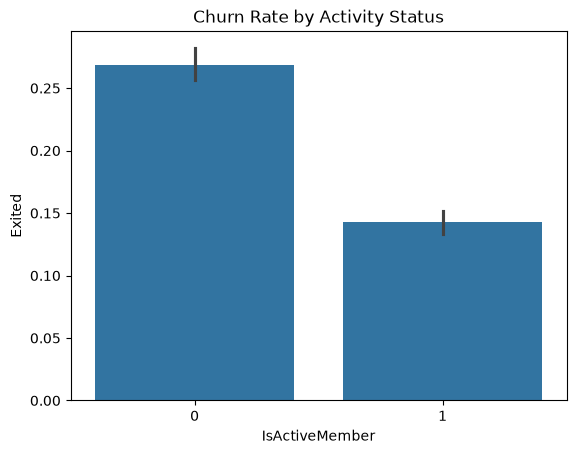

In [38]:
#engagement classification
#active vs inactive customers

sns.barplot( x = 'IsActiveMember', y = 'Exited', data = df)
plt.title('Churn Rate by Activity Status')
plt.show()

In [39]:
#products vs churn
pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


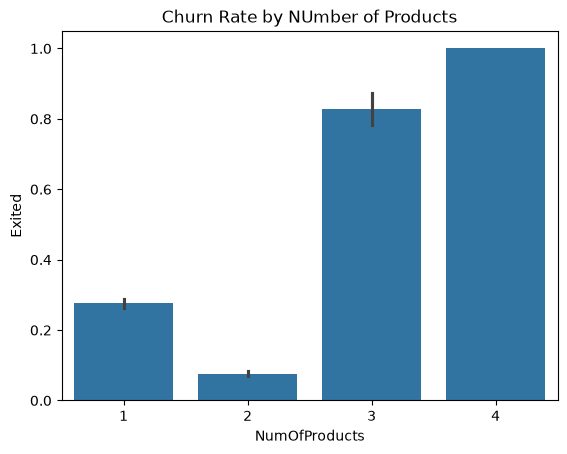

In [40]:
sns.barplot( x ='NumOfProducts', y = 'Exited', data =df)
plt.title('Churn Rate by NUmber of Products')
plt.show()

In [41]:
#credit card vs churn
pd.crosstab(
    df['HasCrCard'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


<Axes: xlabel='Exited', ylabel='Age'>

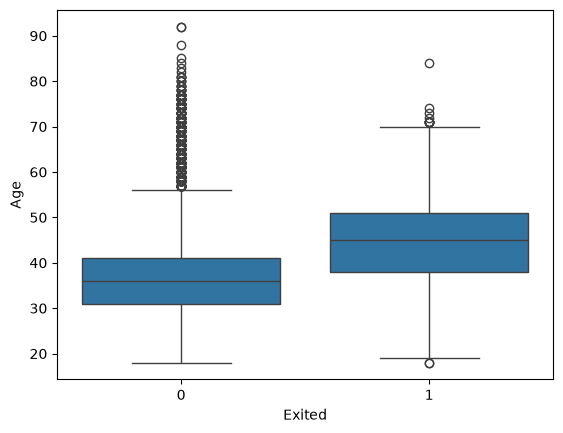

In [42]:
#age vs churn
sns.boxplot(
    x = 'Exited',
    y = 'Age',
    data = df
)

In [43]:
# product utilization analysis

# churn rate by product count
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

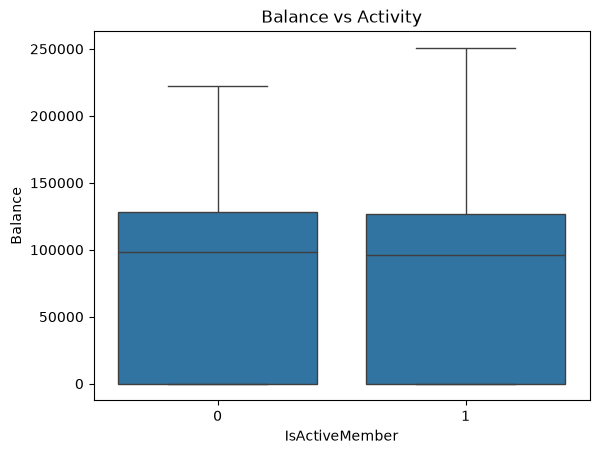

In [44]:
# balance vs activity

sns.boxplot( x = 'IsActiveMember', y = 'Balance', data = df)
plt.title('Balance vs Activity')
plt.show()

**Observations from Busness Analysis:**
-	Customers from Germany churn more than Spain and France.
-	Customers that are inactive churn more.
-	Customers having product 3 churn more comparatively than product 1 and 2.
-	All the customers having product 4 churns.
-	Customer having or not having a credit card does not affect the churn, the churn number for both the cases is almost same.

## Phase 6: KPI Engineering

In [45]:
# engagement retention ratio

active_churn = df[df['IsActiveMember'] == 1]['Exited'].mean()
inactive_churn = df[df['IsActiveMember'] == 0]['Exited'].mean()
engagement_retention_ratio = inactive_churn/active_churn
print(f"active_churn: {active_churn:4f}")
print(f"inactive_churn: {inactive_churn:4f}")
print(f"Engagement Retention Ratio: {engagement_retention_ratio:4f}")

active_churn: 0.142691
inactive_churn: 0.268509
Engagement Retention Ratio: 1.881755


In [46]:
# product depth index

# avergae products per customer

product_depth_index = df['NumOfProducts'].mean()
print('Product Depth Index: ', product_depth_index)

Product Depth Index:  1.5302


In [47]:
# High-Balance Disengagement Rate
high_balance_customers = df[df['Balance'] > balance_median]
high_balance_disengagement_rate = high_balance_customers[high_balance_customers['IsActiveMember'] == 0].shape[0] / high_balance_customers.shape[0] * 100
print(f"High-Balance Disengagement Rate: {high_balance_disengagement_rate:.2f}%")

High-Balance Disengagement Rate: 49.12%


In [48]:
# Credit Card Effectiveness Score
churn_with_card = df[df['HasCrCard'] == 1]['Exited'].mean()
churn_without_card = df[df['HasCrCard'] == 0]['Exited'].mean()
credit_card_effectiveness_score = churn_without_card - churn_with_card

print(f"Churn with Credit Card: {churn_with_card:.4f}")
print(f"Churn without Credit Card: {churn_without_card:.4f}")
print(f"Credit Card Effectiveness Score: {credit_card_effectiveness_score:.4f}")

Churn with Credit Card: 0.2018
Churn without Credit Card: 0.2081
Credit Card Effectiveness Score: 0.0063


In [49]:
# Relationship Strength Index - combined engagement and product score
df['RelationshipStrengthIndex'] = df['IsActiveMember'] + (df['NumOfProducts'] / df['NumOfProducts'].max())
print('Average Relationship Strength Index:', df['RelationshipStrengthIndex'].mean())

Average Relationship Strength Index: 0.89765


In [50]:
# relationship strength vs churn
df.groupby(pd.cut(df['RelationshipStrengthIndex'], bins=3))['Exited'].mean()

RelationshipStrengthIndex
(0.248, 0.833]    0.263802
(0.833, 1.417]    0.198921
(1.417, 2.0]      0.096600
Name: Exited, dtype: float64

In [51]:
# data transformation

In [52]:
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [53]:
target = 'Exited'
numeric_features = df.select_dtypes(include=[int,float]).columns.tolist()
numeric_features.remove(target)
cat_features = df.select_dtypes(include='object').columns.tolist()

print('Numeric Features: ',numeric_features)
print('Categorical Features: ', cat_features)

Numeric Features:  ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'SalaryBalanceMismatch', 'AtRiskPremium', 'StickyCustomer', 'RelationshipStrengthIndex']
Categorical Features:  ['Geography', 'Gender', 'EngagementSegment']


In [54]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers = [
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, cat_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [55]:
#spilting into x and y

from sklearn.model_selection import train_test_split

x = df.drop('Exited', axis = 1)
y = df['Exited']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [56]:
#model training

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

xtrain_transformed = preprocessor.fit_transform(xtrain)
xtest_transformed = preprocessor.transform(xtest)

In [57]:
results = []

In [58]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

best_model = None
best_model_name = ""
best_generalization_score = 0

for name, model in models.items():

    # Train
    model.fit(xtrain_transformed, ytrain)

    # Predictions
    ytrain_pred = model.predict(xtrain_transformed)
    ytest_pred = model.predict(xtest_transformed)

    # Train and test score
    train_score = accuracy_score(ytrain, ytrain_pred)
    test_score = accuracy_score(ytest, ytest_pred)

    # Generalization
    gap = abs(train_score - test_score)
    generalization_score = test_score - gap

    # Evaluation metrics
    precision = precision_score(ytest, ytest_pred)
    recall = recall_score(ytest, ytest_pred)
    f1 = f1_score(ytest, ytest_pred)

    # ROC-AUC
    ytest_prob = model.predict_proba(xtest_transformed)[:, 1]
    roc_auc = roc_auc_score(ytest, ytest_prob)

    # Confusion Matrix
    cm = confusion_matrix(ytest, ytest_pred)

    results.append({
    'Model': name,
    'Train Accuracy': train_score,
    'Test Accuracy': test_score,
    'Gap': gap,
    'Generalization Score': generalization_score,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC-AUC': roc_auc
})
    
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    print(f"Train Accuracy        : {train_score:.4f}")
    print(f"Test Accuracy         : {test_score:.4f}")
    print(f"Gap                   : {gap:.4f}")
    print(f"Generalization Score  : {generalization_score:.4f}")

    print(f"Precision             : {precision:.4f}")
    print(f"Recall                : {recall:.4f}")
    print(f"F1 Score              : {f1:.4f}")
    print(f"ROC-AUC               : {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Select best model based on generalization
    if generalization_score > best_generalization_score:

        best_generalization_score = generalization_score
        best_model = model
        best_model_name = name

print("\nBest Model :", best_model_name)


Logistic Regression
Train Accuracy        : 0.8106
Test Accuracy         : 0.8110
Gap                   : 0.0004
Generalization Score  : 0.8106
Precision             : 0.5497
Recall                : 0.2112
F1 Score              : 0.3051
ROC-AUC               : 0.7853

Confusion Matrix:
[[1539   68]
 [ 310   83]]

Random Forest
Train Accuracy        : 1.0000
Test Accuracy         : 0.8665
Gap                   : 0.1335
Generalization Score  : 0.7330
Precision             : 0.7386
Recall                : 0.4962
F1 Score              : 0.5936
ROC-AUC               : 0.8519

Confusion Matrix:
[[1538   69]
 [ 198  195]]

Gradient Boosting
Train Accuracy        : 0.8714
Test Accuracy         : 0.8630
Gap                   : 0.0084
Generalization Score  : 0.8546
Precision             : 0.7315
Recall                : 0.4784
F1 Score              : 0.5785
ROC-AUC               : 0.8692

Confusion Matrix:
[[1538   69]
 [ 205  188]]

Best Model : Gradient Boosting


In [59]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Gap,Generalization Score,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.810625,0.8110,0.000375,0.810625,0.549669,0.211196,0.305147,0.785344
1,Random Forest,1.000000,0.8665,0.133500,0.733000,0.738636,0.496183,0.593607,0.851911
2,Gradient Boosting,0.871375,0.8630,0.008375,0.854625,0.731518,0.478372,0.578462,0.869238


## Phase 8: Pipeline Creation

In [60]:
#pipeline creation

final_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

final_pipeline.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['CreditScore','Geography','Gender',...,'AtRiskPremium','StickyCustomer', 'RelationshipStrengthIndex']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [61]:
#saving model
import pickle 
pickle.dump(final_pipeline, open('model.pkl', 'wb'))